# 06 — Incremental Feature-Group Comparison

This notebook evaluates how much information is gained by adding climate exposure, disaster history, socioeconomic and affordability conditions, NFIP loss history, and spatial context to housing-market indicators. A fixed Logistic Regression pipeline is applied to five cumulative feature groups so performance changes can be attributed to the added information rather than a change of model.

**Input:** `data/processed/florida_county_year_vulnerability_2011_2025.csv`  
**Outputs:** feature-group metrics, fold-level results, class-wise diagnostics, statistical-test summaries, definitions, predictions, and four report-ready figures.

The 2023–2025 sample is a **later-period held-out evaluation**. The target classes were constructed from the complete 2011–2025 panel in Notebook 04, so the analysis measures class reproducibility rather than prospective forecasting.


## 1. Setup

Paths, study years, the random seed, and semantic colours come from the shared project modules. All tables and figures retain the filenames expected by Notebook 08 and the report appendices.


In [1]:
import json
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from IPython.display import Image, display
from scipy.stats import t, ttest_rel
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def locate_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (  # noqa: E402
    PROJECT_COLORS,
    RANDOM_STATE,
    STUDY_END_YEAR,
    STUDY_START_YEAR,
    TEST_START_YEAR,
    TRAIN_END_YEAR,
)
from src.visualization import save_figure, save_table  # noqa: E402

INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "florida_county_year_vulnerability_2011_2025.csv"
)
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables" / "feature_group_comparison"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures" / "feature_group_comparison"
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = ["Low", "Medium", "High"]
CLASS_COLORS = {
    "Low": PROJECT_COLORS["resilience"],
    "Medium": PROJECT_COLORS["nfip"],
    "High": PROJECT_COLORS["disaster"],
}

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
print(f"Input: {INPUT_PATH}")


Project root: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation
Input: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\data\processed\florida_county_year_vulnerability_2011_2025.csv


## 2. Load and validate the modelling dataset

Notebook 04 is the only required upstream stage. The checks below protect the county-year panel, balanced target, and expected 2011–2025 coverage before feature groups are defined.


In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Run cleaned Notebook 04 first. Missing input: " f"{INPUT_PATH}"
    )

county_year_data = pd.read_csv(INPUT_PATH, dtype={"STCOFIPS": "string"})
county_year_data["STCOFIPS"] = county_year_data["STCOFIPS"].str.zfill(5)
county_year_data = county_year_data.sort_values(
    ["Year", "STCOFIPS"]
).reset_index(drop=True)

required_columns = {"Year", "STCOFIPS", "RegionName", "vulnerability_class"}
missing_required = required_columns.difference(county_year_data.columns)
if missing_required:
    raise KeyError(f"Missing required columns: {sorted(missing_required)}")

duplicate_count = int(county_year_data.duplicated(["STCOFIPS", "Year"]).sum())
class_counts = county_year_data["vulnerability_class"].value_counts()

assert duplicate_count == 0, "Duplicate county-year rows detected."
assert county_year_data["vulnerability_class"].notna().all()
assert set(class_counts.index) == set(CLASS_ORDER)
assert county_year_data["Year"].min() == STUDY_START_YEAR
assert county_year_data["Year"].max() == STUDY_END_YEAR

dataset_audit = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Columns",
            "Counties",
            "Year range",
            "Duplicate county-years",
            "Missing targets",
        ],
        "value": [
            len(county_year_data),
            county_year_data.shape[1],
            county_year_data["STCOFIPS"].nunique(),
            f"{county_year_data['Year'].min()}–{county_year_data['Year'].max()}",
            duplicate_count,
            int(county_year_data["vulnerability_class"].isna().sum()),
        ],
    }
)

display(dataset_audit)
display(class_counts.rename("observations").to_frame())


,check,value
0,Rows,1000
1,Columns,123
2,Counties,67
3,Year range,2011–2025
4,Duplicate county-years,0
5,Missing targets,0


,observations
vulnerability_class,
Low,334
Medium,333
High,333


## 3. Define cumulative feature groups

Every group includes `Year` as a common temporal control. Layers are cumulative: each specification contains all predictors from the preceding group. The Full Model is the same 67-predictor leakage-safe specification evaluated in Notebook 05.


In [3]:
TEMPORAL_FEATURES = ["Year"]
HOUSING_FEATURES = [
    "avg_annual_housing_price",
    "median_annual_housing_price",
    "min_annual_housing_price",
    "max_annual_housing_price",
    "annual_price_volatility",
    "monthly_observations",
    "prev_year_housing_price",
    "annual_price_growth_dollar",
    "annual_price_growth_pct",
    "baseline_housing_price",
    "appreciation_from_baseline_pct",
    "price_growth_acceleration",
    "high_growth_flag",
    "high_volatility_flag",
    "complete_year_flag",
]
CLIMATE_FEATURES = ["CFLD_RISKS", "HRCN_RISKS"]
DISASTER_FEATURES = [
    "disaster_count",
    "unique_disaster_events",
    "climate_disaster_count",
    "hurricane_disaster_count",
    "tropical_storm_disaster_count",
    "severe_storm_disaster_count",
    "flood_disaster_count",
    "fire_disaster_count",
    "any_disaster_flag",
    "any_climate_disaster_flag",
    "cumulative_disaster_count",
    "cumulative_climate_disaster_count",
    "recent_3yr_disaster_count",
    "recent_3yr_climate_disaster_count",
]
ACS_AFFORDABILITY_FEATURES = [
    "SizeRank",
    "POPULATION",
    "SOVI_SCORE",
    "RESL_SCORE",
    "is_metro",
    "acs_total_population",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "owner_occupied_share",
    "renter_occupied_share",
    "median_gross_rent",
    "acs_median_home_value",
    "price_to_income_ratio",
    "acs_estimated_2025_flag",
]
NFIP_FEATURES = [
    "nfip_claim_count",
    "nfip_policy_count_sum",
    "nfip_total_building_payment",
    "nfip_total_contents_payment",
    "nfip_total_icc_payment",
    "nfip_total_claim_payment",
    "nfip_avg_claim_payment",
    "nfip_total_building_coverage",
    "nfip_total_contents_coverage",
    "nfip_cumulative_claim_count",
    "nfip_cumulative_claim_payment",
    "nfip_recent_3yr_claim_count",
    "nfip_recent_3yr_claim_payment",
    "nfip_claim_year_indicator",
]
SPATIAL_FEATURES = [
    "neighbor_count",
    "neighbor_avg_housing_price",
    "neighbor_avg_price_growth_pct",
    "neighbor_avg_price_volatility",
    "neighbor_high_growth_share",
    "neighbor_high_volatility_share",
]

FEATURE_GROUPS = {
    "Housing Only": TEMPORAL_FEATURES + HOUSING_FEATURES,
    "Housing + Climate": TEMPORAL_FEATURES + HOUSING_FEATURES + CLIMATE_FEATURES,
    "Housing + Climate + Disaster": (
        TEMPORAL_FEATURES + HOUSING_FEATURES + CLIMATE_FEATURES + DISASTER_FEATURES
    ),
    "Housing + Climate + Disaster + ACS": (
        TEMPORAL_FEATURES
        + HOUSING_FEATURES
        + CLIMATE_FEATURES
        + DISASTER_FEATURES
        + ACS_AFFORDABILITY_FEATURES
    ),
    "Full Model": (
        TEMPORAL_FEATURES
        + HOUSING_FEATURES
        + CLIMATE_FEATURES
        + DISASTER_FEATURES
        + ACS_AFFORDABILITY_FEATURES
        + NFIP_FEATURES
        + SPATIAL_FEATURES
    ),
}

FEATURE_GROUP_ORDER = list(FEATURE_GROUPS)
EXPECTED_GROUP_SIZES = [16, 18, 32, 47, 67]
display(
    pd.DataFrame(
        {
            "feature_group": FEATURE_GROUP_ORDER,
            "number_of_features": [len(FEATURE_GROUPS[g]) for g in FEATURE_GROUP_ORDER],
        }
    )
)


,feature_group,number_of_features
0,Housing Only,16
1,Housing + Climate,18
2,Housing + Climate + Disaster,32
3,Housing + Climate + Disaster + ACS,47
4,Full Model,67


## 4. Validate feature availability and leakage controls

The composite target, score components, scoring transformations, log helpers, and identifiers are prohibited. Validation fails explicitly if a requested feature is missing, nonnumeric, duplicated, or overlaps an excluded column.


In [4]:
FINAL_SCORE_COLUMNS = [
    "vulnerability_class",
    "climate_housing_vulnerability_score",
]
SUBSCORE_COLUMNS = [
    "housing_pressure_score",
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score",
]
METADATA_COLUMNS = [
    "STCOFIPS",
    "RegionID",
    "RegionName",
    "State",
    "Metro",
    "StateCodeFIPS",
    "MunicipalCodeFIPS",
    "COUNTY",
]
EXCLUDED_COLUMNS = set(
    FINAL_SCORE_COLUMNS
    + SUBSCORE_COLUMNS
    + [c for c in county_year_data if c.startswith("scaled_")]
    + [c for c in county_year_data if c.startswith("log_")]
    + METADATA_COLUMNS
)

validated_feature_groups = {}
validation_rows = []
previous_group = set()

for expected_size, (group_name, requested_features) in zip(
    EXPECTED_GROUP_SIZES, FEATURE_GROUPS.items()
):
    missing = [c for c in requested_features if c not in county_year_data]
    leakage = sorted(set(requested_features).intersection(EXCLUDED_COLUMNS))
    duplicates = len(requested_features) - len(set(requested_features))
    available = [c for c in requested_features if c in county_year_data]
    numeric = county_year_data[available].select_dtypes(include=np.number).columns.tolist()
    nonnumeric = sorted(set(available).difference(numeric))

    assert not missing, f"{group_name} missing features: {missing}"
    assert not leakage, f"{group_name} leakage columns: {leakage}"
    assert duplicates == 0, f"{group_name} contains duplicate predictors."
    assert not nonnumeric, f"{group_name} nonnumeric features: {nonnumeric}"
    assert len(numeric) == expected_size
    assert previous_group.issubset(numeric)

    validated_feature_groups[group_name] = numeric
    validation_rows.append(
        {
            "feature_group": group_name,
            "requested_features": len(requested_features),
            "available_features": len(available),
            "numeric_features": len(numeric),
            "missing_features": len(missing),
            "leakage_columns_found": len(leakage),
        }
    )
    previous_group = set(numeric)

feature_group_validation = pd.DataFrame(validation_rows)
display(feature_group_validation)


,feature_group,requested_features,available_features,numeric_features,missing_features,leakage_columns_found
0,Housing Only,16,16,16,0,0
1,Housing + Climate,18,18,18,0,0
2,Housing + Climate + Disaster,32,32,32,0,0
3,Housing + Climate + Disaster + ACS,47,47,47,0,0
4,Full Model,67,67,67,0,0


## 5. Temporal evaluation design

The fixed training period is 2011–2022 and the later-period holdout is 2023–2025. Five expanding-window folds reproduce the design used in Notebook 05. Imputation and scaling are fitted separately inside every fold.


In [5]:
TARGET_COLUMN = "vulnerability_class"
y = county_year_data[TARGET_COLUMN]
train_mask = county_year_data["Year"].le(TRAIN_END_YEAR)
test_mask = county_year_data["Year"].ge(TEST_START_YEAR)

CV_FOLD_DEFINITIONS = [
    {"fold": "Fold 1", "validation_start_year": 2015, "validation_end_year": 2016},
    {"fold": "Fold 2", "validation_start_year": 2017, "validation_end_year": 2018},
    {"fold": "Fold 3", "validation_start_year": 2019, "validation_end_year": 2020},
    {"fold": "Fold 4", "validation_start_year": 2021, "validation_end_year": 2021},
    {"fold": "Fold 5", "validation_start_year": 2022, "validation_end_year": 2022},
]

temporal_folds = []
fold_summary_rows = []
for definition in CV_FOLD_DEFINITIONS:
    start = definition["validation_start_year"]
    end = definition["validation_end_year"]
    fold_train = county_year_data["Year"].lt(start) & train_mask
    fold_valid = county_year_data["Year"].between(start, end) & train_mask
    assert county_year_data.loc[fold_train, "Year"].max() < start

    temporal_folds.append(
        {
            **definition,
            "train_mask": fold_train,
            "validation_mask": fold_valid,
        }
    )
    fold_summary_rows.append(
        {
            "fold": definition["fold"],
            "train_years": (
                f"{county_year_data.loc[fold_train, 'Year'].min()}-"
                f"{county_year_data.loc[fold_train, 'Year'].max()}"
            ),
            "validation_years": f"{start}-{end}",
            "train_rows": int(fold_train.sum()),
            "validation_rows": int(fold_valid.sum()),
            "train_low": int(y.loc[fold_train].eq("Low").sum()),
            "train_medium": int(y.loc[fold_train].eq("Medium").sum()),
            "train_high": int(y.loc[fold_train].eq("High").sum()),
            "validation_low": int(y.loc[fold_valid].eq("Low").sum()),
            "validation_medium": int(y.loc[fold_valid].eq("Medium").sum()),
            "validation_high": int(y.loc[fold_valid].eq("High").sum()),
        }
    )

cv_fold_summary = pd.DataFrame(fold_summary_rows)
split_summary = pd.concat(
    {
        "Training (2011–2022)": y.loc[train_mask].value_counts(),
        "Held out (2023–2025)": y.loc[test_mask].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

display(split_summary)
display(cv_fold_summary)


,Training (2011–2022),Held out (2023–2025)
vulnerability_class,,
Low,281,53
High,264,69
Medium,254,79


,fold,train_years,validation_years,train_rows,validation_rows,train_low,train_medium,train_high,validation_low,validation_medium,validation_high
0,Fold 1,2011-2014,2015-2016,264,133,166,76,22,52,46,35
1,Fold 2,2011-2016,2017-2018,397,134,218,122,57,27,48,59
2,Fold 3,2011-2018,2019-2020,531,134,245,170,116,32,53,49
3,Fold 4,2011-2020,2021-2021,665,67,277,223,165,3,25,39
4,Fold 5,2011-2021,2022-2022,732,67,280,248,204,1,6,60


## 6. Evaluate the fixed Logistic Regression pipeline

The model specification is identical across groups: median imputation, standardization, and multinomial Logistic Regression. Macro F1 is the primary metric because it gives equal weight to Low, Medium, and High classes.


In [6]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }


def logistic_pipeline():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
            ),
        ]
    )


def evaluate_feature_group(group_name, features):
    fold_rows = []
    for fold in temporal_folds:
        model = clone(logistic_pipeline())
        model.fit(
            county_year_data.loc[fold["train_mask"], features],
            y.loc[fold["train_mask"]],
        )
        predictions = model.predict(
            county_year_data.loc[fold["validation_mask"], features]
        )
        metrics = classification_metrics(y.loc[fold["validation_mask"]], predictions)
        metrics.update(
            {
                "feature_group": group_name,
                "fold": fold["fold"],
                "validation_years": (
                    f"{fold['validation_start_year']}-{fold['validation_end_year']}"
                ),
                "number_of_features": len(features),
            }
        )
        fold_rows.append(metrics)

    final_model = clone(logistic_pipeline())
    final_model.fit(county_year_data.loc[train_mask, features], y.loc[train_mask])
    holdout_predictions = final_model.predict(
        county_year_data.loc[test_mask, features]
    )
    holdout_metrics = classification_metrics(y.loc[test_mask], holdout_predictions)
    holdout_metrics.update(
        {"feature_group": group_name, "number_of_features": len(features)}
    )

    prediction_table = county_year_data.loc[
        test_mask, ["Year", "STCOFIPS", "RegionName"]
    ].reset_index(drop=True)
    prediction_table.insert(0, "feature_group", group_name)
    prediction_table["actual_vulnerability_class"] = y.loc[test_mask].reset_index(
        drop=True
    )
    prediction_table["predicted_vulnerability_class"] = holdout_predictions

    return {
        "cv": pd.DataFrame(fold_rows),
        "holdout_metrics": holdout_metrics,
        "predictions": prediction_table,
        "model": final_model,
    }


group_outputs = {}
for group_name, features in validated_feature_groups.items():
    print(f"Evaluating {group_name} ({len(features)} predictors)...")
    group_outputs[group_name] = evaluate_feature_group(group_name, features)

cv_results = pd.concat(
    [output["cv"] for output in group_outputs.values()], ignore_index=True
)
holdout_results = pd.DataFrame(
    [output["holdout_metrics"] for output in group_outputs.values()]
)
test_predictions = pd.concat(
    [output["predictions"] for output in group_outputs.values()], ignore_index=True
)

print(f"Fold results: {cv_results.shape}")
print(f"Held-out results: {holdout_results.shape}")
print(f"Predictions: {test_predictions.shape}")


Evaluating Housing Only (16 predictors)...
Evaluating Housing + Climate (18 predictors)...
Evaluating Housing + Climate + Disaster (32 predictors)...
Evaluating Housing + Climate + Disaster + ACS (47 predictors)...
Evaluating Full Model (67 predictors)...
Fold results: (25, 9)
Held-out results: (5, 7)
Predictions: (1005, 6)


## 7. Overall and marginal performance

The cumulative comparison separates two questions: how reliably each group performs across the five temporal folds, and how well it reproduces classes in the later 2023–2025 period. Marginal changes should therefore be read alongside both CV stability and held-out performance.


In [7]:
cv_summary_by_group = (
    cv_results.groupby("feature_group")
    .agg(
        cv_macro_f1_mean=("macro_f1", "mean"),
        cv_macro_f1_std=("macro_f1", "std"),
    )
    .reset_index()
)
holdout_summary = holdout_results.rename(
    columns={
        "accuracy": "test_accuracy",
        "macro_precision": "test_macro_precision",
        "macro_recall": "test_macro_recall",
        "macro_f1": "test_macro_f1",
        "weighted_f1": "test_weighted_f1",
    }
)

feature_group_comparison = cv_summary_by_group.merge(
    holdout_summary, on="feature_group", how="left"
)
feature_group_comparison["feature_group"] = pd.Categorical(
    feature_group_comparison["feature_group"],
    categories=FEATURE_GROUP_ORDER,
    ordered=True,
)
feature_group_comparison = feature_group_comparison.sort_values(
    "feature_group"
).reset_index(drop=True)
feature_group_comparison = feature_group_comparison[
    [
        "feature_group",
        "number_of_features",
        "cv_macro_f1_mean",
        "cv_macro_f1_std",
        "test_macro_f1",
        "test_accuracy",
        "test_macro_precision",
        "test_macro_recall",
        "test_weighted_f1",
    ]
]

ADDED_LAYER_LABELS = [
    "Housing baseline",
    "+ Climate exposure",
    "+ Disaster history",
    "+ ACS / socioeconomic / affordability",
    "+ NFIP insurance-loss + spatial spillovers",
]
marginal_contribution = feature_group_comparison.copy()
marginal_contribution.insert(1, "added_layer", ADDED_LAYER_LABELS)
for metric in ["test_macro_f1", "test_accuracy", "test_weighted_f1"]:
    marginal_contribution[f"delta_{metric}"] = marginal_contribution[metric].diff()
marginal_contribution["delta_cv_macro_f1_mean"] = marginal_contribution[
    "cv_macro_f1_mean"
].diff()
marginal_contribution = marginal_contribution[
    [
        "feature_group",
        "added_layer",
        "number_of_features",
        "test_macro_f1",
        "delta_test_macro_f1",
        "test_accuracy",
        "delta_test_accuracy",
        "test_weighted_f1",
        "delta_test_weighted_f1",
        "cv_macro_f1_mean",
        "delta_cv_macro_f1_mean",
    ]
]

display(feature_group_comparison)
display(marginal_contribution)


,feature_group,number_of_features,cv_macro_f1_mean,cv_macro_f1_std,test_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_weighted_f1
0,Housing Only,16,0.3784,0.1118,0.2847,0.3632,0.4526,0.3433,0.3014
1,Housing + Climate,18,0.6142,0.0683,0.4599,0.5025,0.5784,0.4741,0.4757
2,Housing + Climate + Disaster,32,0.6663,0.1120,0.6931,0.6915,0.7440,0.6901,0.6874
3,Housing + Climate + Disaster + ACS,47,0.6203,0.1424,0.7453,0.7413,0.7509,0.7575,0.7419
4,Full Model,67,0.7345,0.1097,0.7687,0.7761,0.8038,0.8077,0.7622


,feature_group,added_layer,number_of_features,test_macro_f1,delta_test_macro_f1,test_accuracy,delta_test_accuracy,test_weighted_f1,delta_test_weighted_f1,cv_macro_f1_mean,delta_cv_macro_f1_mean
0,Housing Only,Housing baseline,16,0.2847,NaN,0.3632,NaN,0.3014,NaN,0.3784,NaN
1,Housing + Climate,+ Climate exposure,18,0.4599,0.1752,0.5025,0.1393,0.4757,0.1743,0.6142,0.2358
2,Housing + Climate + Disaster,+ Disaster history,32,0.6931,0.2332,0.6915,0.1891,0.6874,0.2117,0.6663,0.0521
3,Housing + Climate + Disaster + ACS,+ ACS / socioeconomic / affordability,47,0.7453,0.0522,0.7413,0.0498,0.7419,0.0545,0.6203,-0.0460
4,Full Model,+ NFIP insurance-loss + spatial spillovers,67,0.7687,0.0234,0.7761,0.0348,0.7622,0.0203,0.7345,0.1142


## 8. Paired climate-addition test

The paired test compares Housing Only with Housing + Climate on the same five temporal validation windows. All folds improve after adding climate exposure. Because there are only five folds and their expanding training samples overlap, the test is best treated as structured supporting evidence rather than a definitive independent-sample inference.


In [8]:
paired_macro_f1 = (
    cv_results.loc[
        cv_results["feature_group"].isin(["Housing Only", "Housing + Climate"]),
        ["fold", "validation_years", "feature_group", "macro_f1"],
    ]
    .pivot(
        index=["fold", "validation_years"],
        columns="feature_group",
        values="macro_f1",
    )
    .reset_index()
    .rename(
        columns={
            "Housing + Climate": "housing_climate_macro_f1",
            "Housing Only": "housing_only_macro_f1",
        }
    )
)
paired_macro_f1["fold"] = pd.Categorical(
    paired_macro_f1["fold"],
    categories=[f"Fold {i}" for i in range(1, 6)],
    ordered=True,
)
paired_macro_f1 = paired_macro_f1.sort_values("fold").reset_index(drop=True)
paired_macro_f1 = paired_macro_f1[
    [
        "fold",
        "validation_years",
        "housing_climate_macro_f1",
        "housing_only_macro_f1",
    ]
]
paired_macro_f1["macro_f1_improvement"] = (
    paired_macro_f1["housing_climate_macro_f1"]
    - paired_macro_f1["housing_only_macro_f1"]
)
assert paired_macro_f1.iloc[:, 2:4].notna().all().all()

t_statistic, p_value = ttest_rel(
    paired_macro_f1["housing_climate_macro_f1"],
    paired_macro_f1["housing_only_macro_f1"],
)
n_pairs = len(paired_macro_f1)
degrees_of_freedom = n_pairs - 1
differences = paired_macro_f1["macro_f1_improvement"]
mean_improvement = differences.mean()
difference_std = differences.std(ddof=1)
standard_error = difference_std / np.sqrt(n_pairs)
critical_t = t.ppf(0.975, degrees_of_freedom)

climate_paired_ttest_summary = pd.DataFrame(
    {
        "baseline_model": ["Housing Only"],
        "enhanced_model": ["Housing + Climate"],
        "evaluation_metric": ["Macro F1"],
        "number_of_temporal_folds": [n_pairs],
        "baseline_mean_macro_f1": [paired_macro_f1["housing_only_macro_f1"].mean()],
        "enhanced_mean_macro_f1": [paired_macro_f1["housing_climate_macro_f1"].mean()],
        "mean_macro_f1_improvement": [mean_improvement],
        "improvement_standard_deviation": [difference_std],
        "t_statistic": [t_statistic],
        "degrees_of_freedom": [degrees_of_freedom],
        "p_value_two_sided": [p_value],
        "confidence_interval_95_lower": [mean_improvement - critical_t * standard_error],
        "confidence_interval_95_upper": [mean_improvement + critical_t * standard_error],
        "cohen_dz": [mean_improvement / difference_std],
        "all_folds_improved": [bool(differences.gt(0).all())],
        "statistically_significant_at_0_05": [bool(p_value < 0.05)],
    }
)

display(paired_macro_f1)
display(climate_paired_ttest_summary)


feature_group,fold,validation_years,housing_climate_macro_f1,housing_only_macro_f1,macro_f1_improvement
0,Fold 1,2015-2016,0.6835,0.5055,0.1780
1,Fold 2,2017-2018,0.6435,0.4828,0.1608
2,Fold 3,2019-2020,0.5561,0.3437,0.2125
3,Fold 4,2021-2021,0.5277,0.2453,0.2824
4,Fold 5,2022-2022,0.6602,0.3150,0.3452


,baseline_model,enhanced_model,evaluation_metric,number_of_temporal_folds,baseline_mean_macro_f1,enhanced_mean_macro_f1,mean_macro_f1_improvement,improvement_standard_deviation,t_statistic,degrees_of_freedom,p_value_two_sided,confidence_interval_95_lower,confidence_interval_95_upper,cohen_dz,all_folds_improved,statistically_significant_at_0_05
0,Housing Only,Housing + Climate,Macro F1,5,0.3784,0.6142,0.2358,0.0769,6.8548,4,0.0024,0.1403,0.3313,3.0656,True,True


## 9. Class-wise and confusion-matrix diagnostics

Overall macro F1 can conceal which vulnerability classes improve. The exported class-wise table and long-form confusion matrices therefore retain precision, recall, and F1 for Low, Medium, and High classes at every cumulative stage.


In [9]:
classwise_rows = []
confusion_rows = []

for group_name in FEATURE_GROUP_ORDER:
    group_predictions = test_predictions.query("feature_group == @group_name")
    actual = group_predictions["actual_vulnerability_class"]
    predicted = group_predictions["predicted_vulnerability_class"]
    report = classification_report(
        actual,
        predicted,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    matrix = confusion_matrix(actual, predicted, labels=CLASS_ORDER)

    for class_name in CLASS_ORDER:
        classwise_rows.append(
            {
                "feature_group": group_name,
                "class": class_name,
                "precision": report[class_name]["precision"],
                "recall": report[class_name]["recall"],
                "f1_score": report[class_name]["f1-score"],
                "support": report[class_name]["support"],
            }
        )
    for actual_index, actual_class in enumerate(CLASS_ORDER):
        for predicted_index, predicted_class in enumerate(CLASS_ORDER):
            confusion_rows.append(
                {
                    "feature_group": group_name,
                    "actual_class": actual_class,
                    "predicted_class": predicted_class,
                    "count": int(matrix[actual_index, predicted_index]),
                }
            )

classwise_performance = pd.DataFrame(classwise_rows)
classwise_performance["feature_group"] = pd.Categorical(
    classwise_performance["feature_group"], FEATURE_GROUP_ORDER, ordered=True
)
classwise_performance["class"] = pd.Categorical(
    classwise_performance["class"], CLASS_ORDER, ordered=True
)
classwise_performance = classwise_performance.sort_values(
    ["feature_group", "class"]
).reset_index(drop=True)
confusion_matrix_long = pd.DataFrame(confusion_rows)

full_model_classwise = classwise_performance.query("feature_group == 'Full Model'")
full_model_confusion = (
    confusion_matrix_long.query("feature_group == 'Full Model'")
    .pivot(index="actual_class", columns="predicted_class", values="count")
    .reindex(index=CLASS_ORDER, columns=CLASS_ORDER)
)

display(full_model_classwise)
display(full_model_confusion)


,feature_group,class,precision,recall,f1_score,support
12,Full Model,Low,0.6163,1.0000,0.7626,53.0000
13,Full Model,Medium,0.9048,0.4810,0.6281,79.0000
14,Full Model,High,0.8904,0.9420,0.9155,69.0000


predicted_class,Low,Medium,High
actual_class,,,
Low,53,0,0
Medium,33,38,8
High,0,4,65


## 10. Report-ready figures

The figures use the project’s semantic palette consistently: housing blue, climate orange, disaster red-orange, socioeconomic conditions purple, NFIP/spatial context gold, and Low/Medium/High class colours held constant across class-wise charts.


Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\feature_group_comparison\feature_group_macro_f1_curve.png
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\feature_group_comparison\feature_group_marginal_contribution.png
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\feature_group_comparison\feature_group_classwise_f1.png
Saved figure: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\feature_group_comparison\feature_group_classwise_recall.png


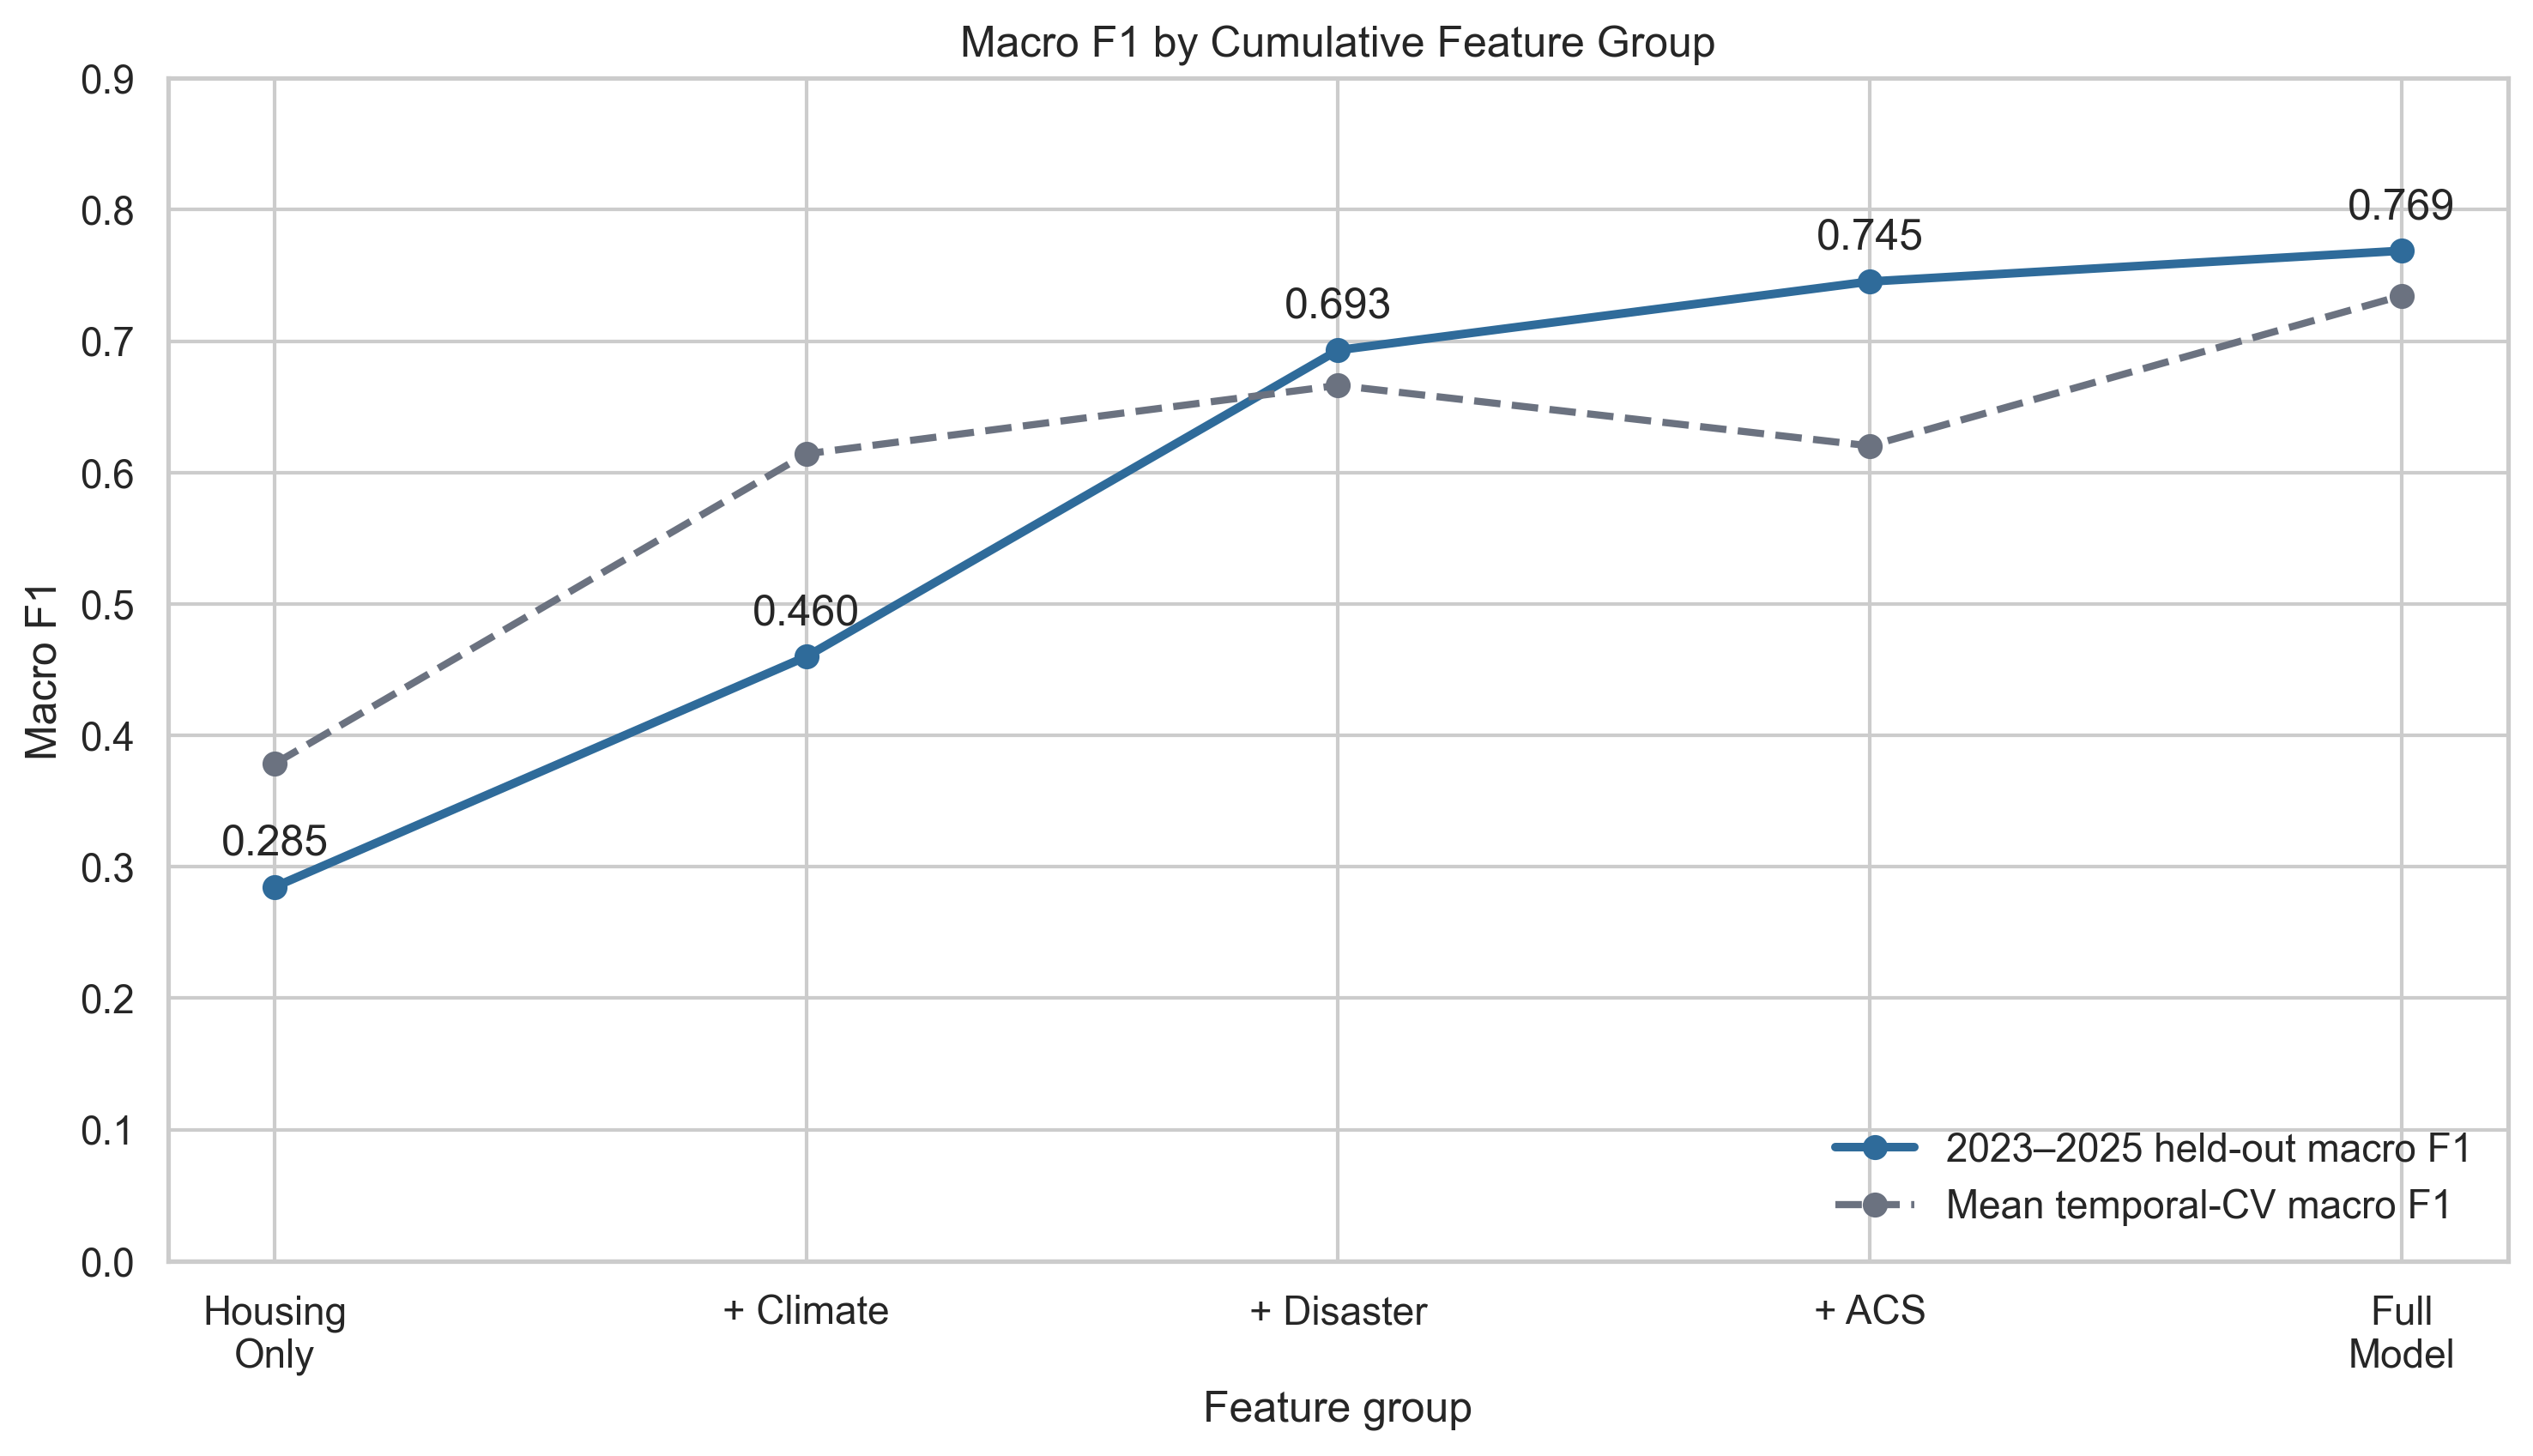

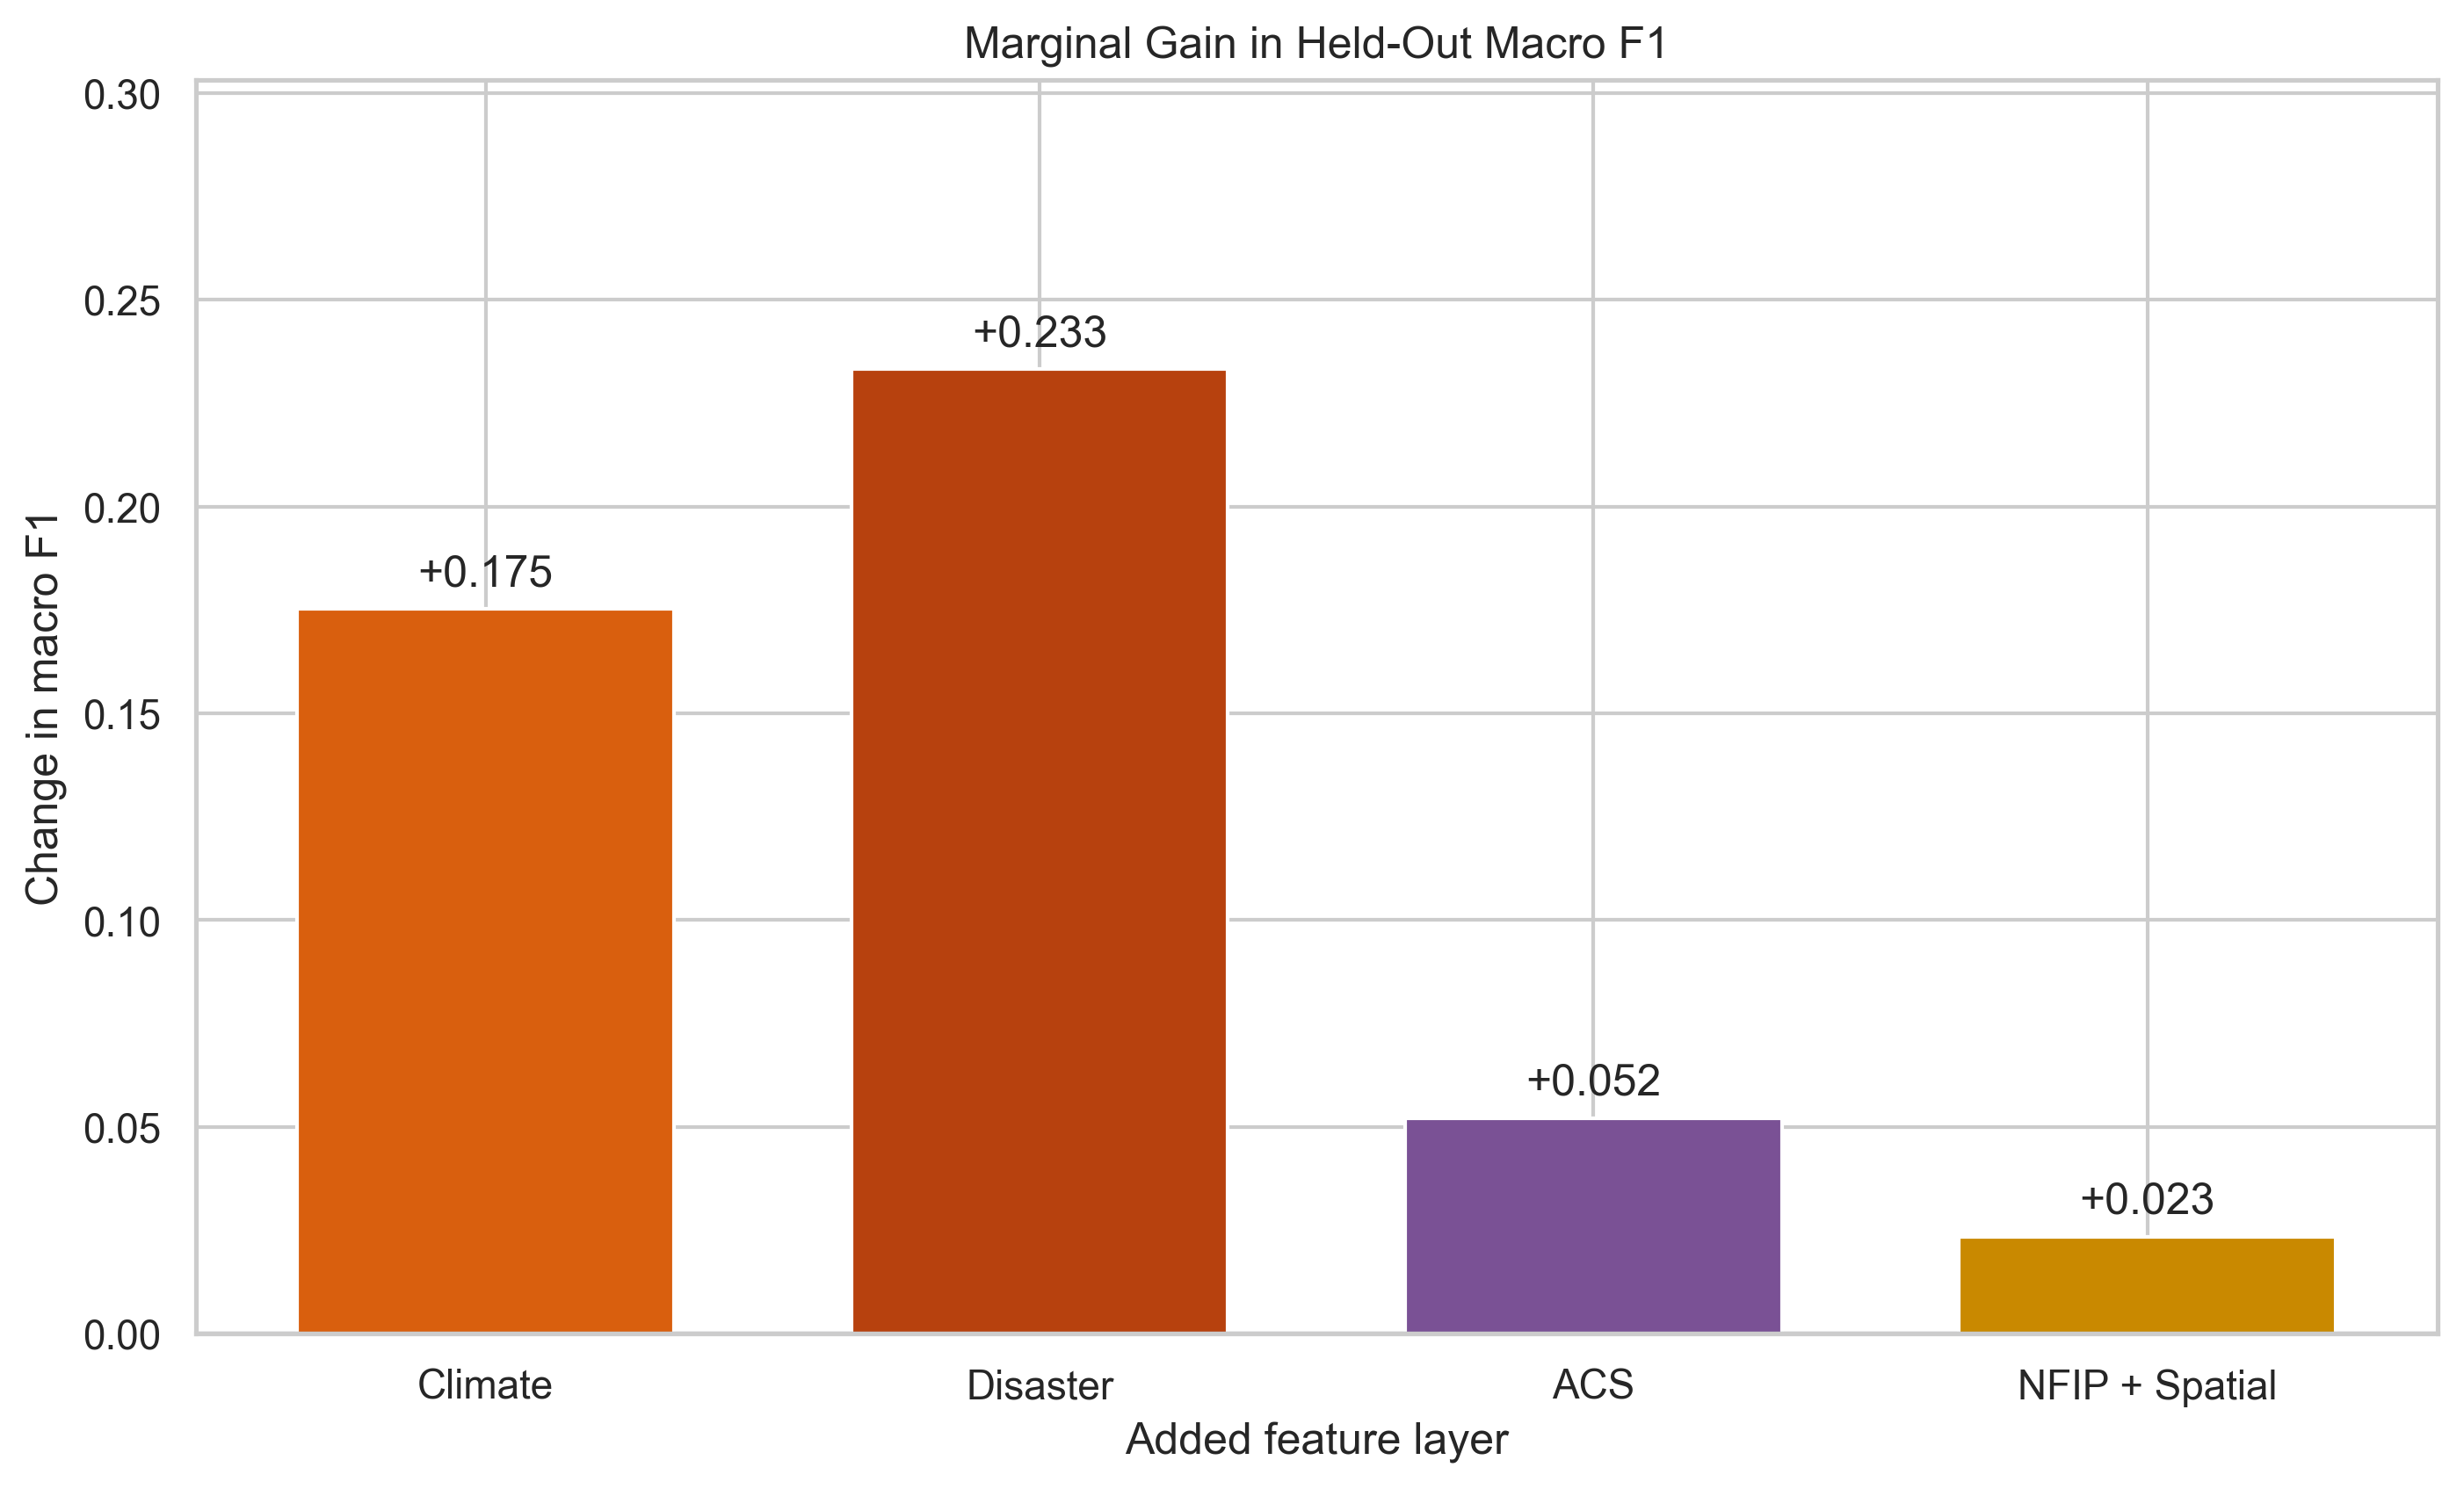

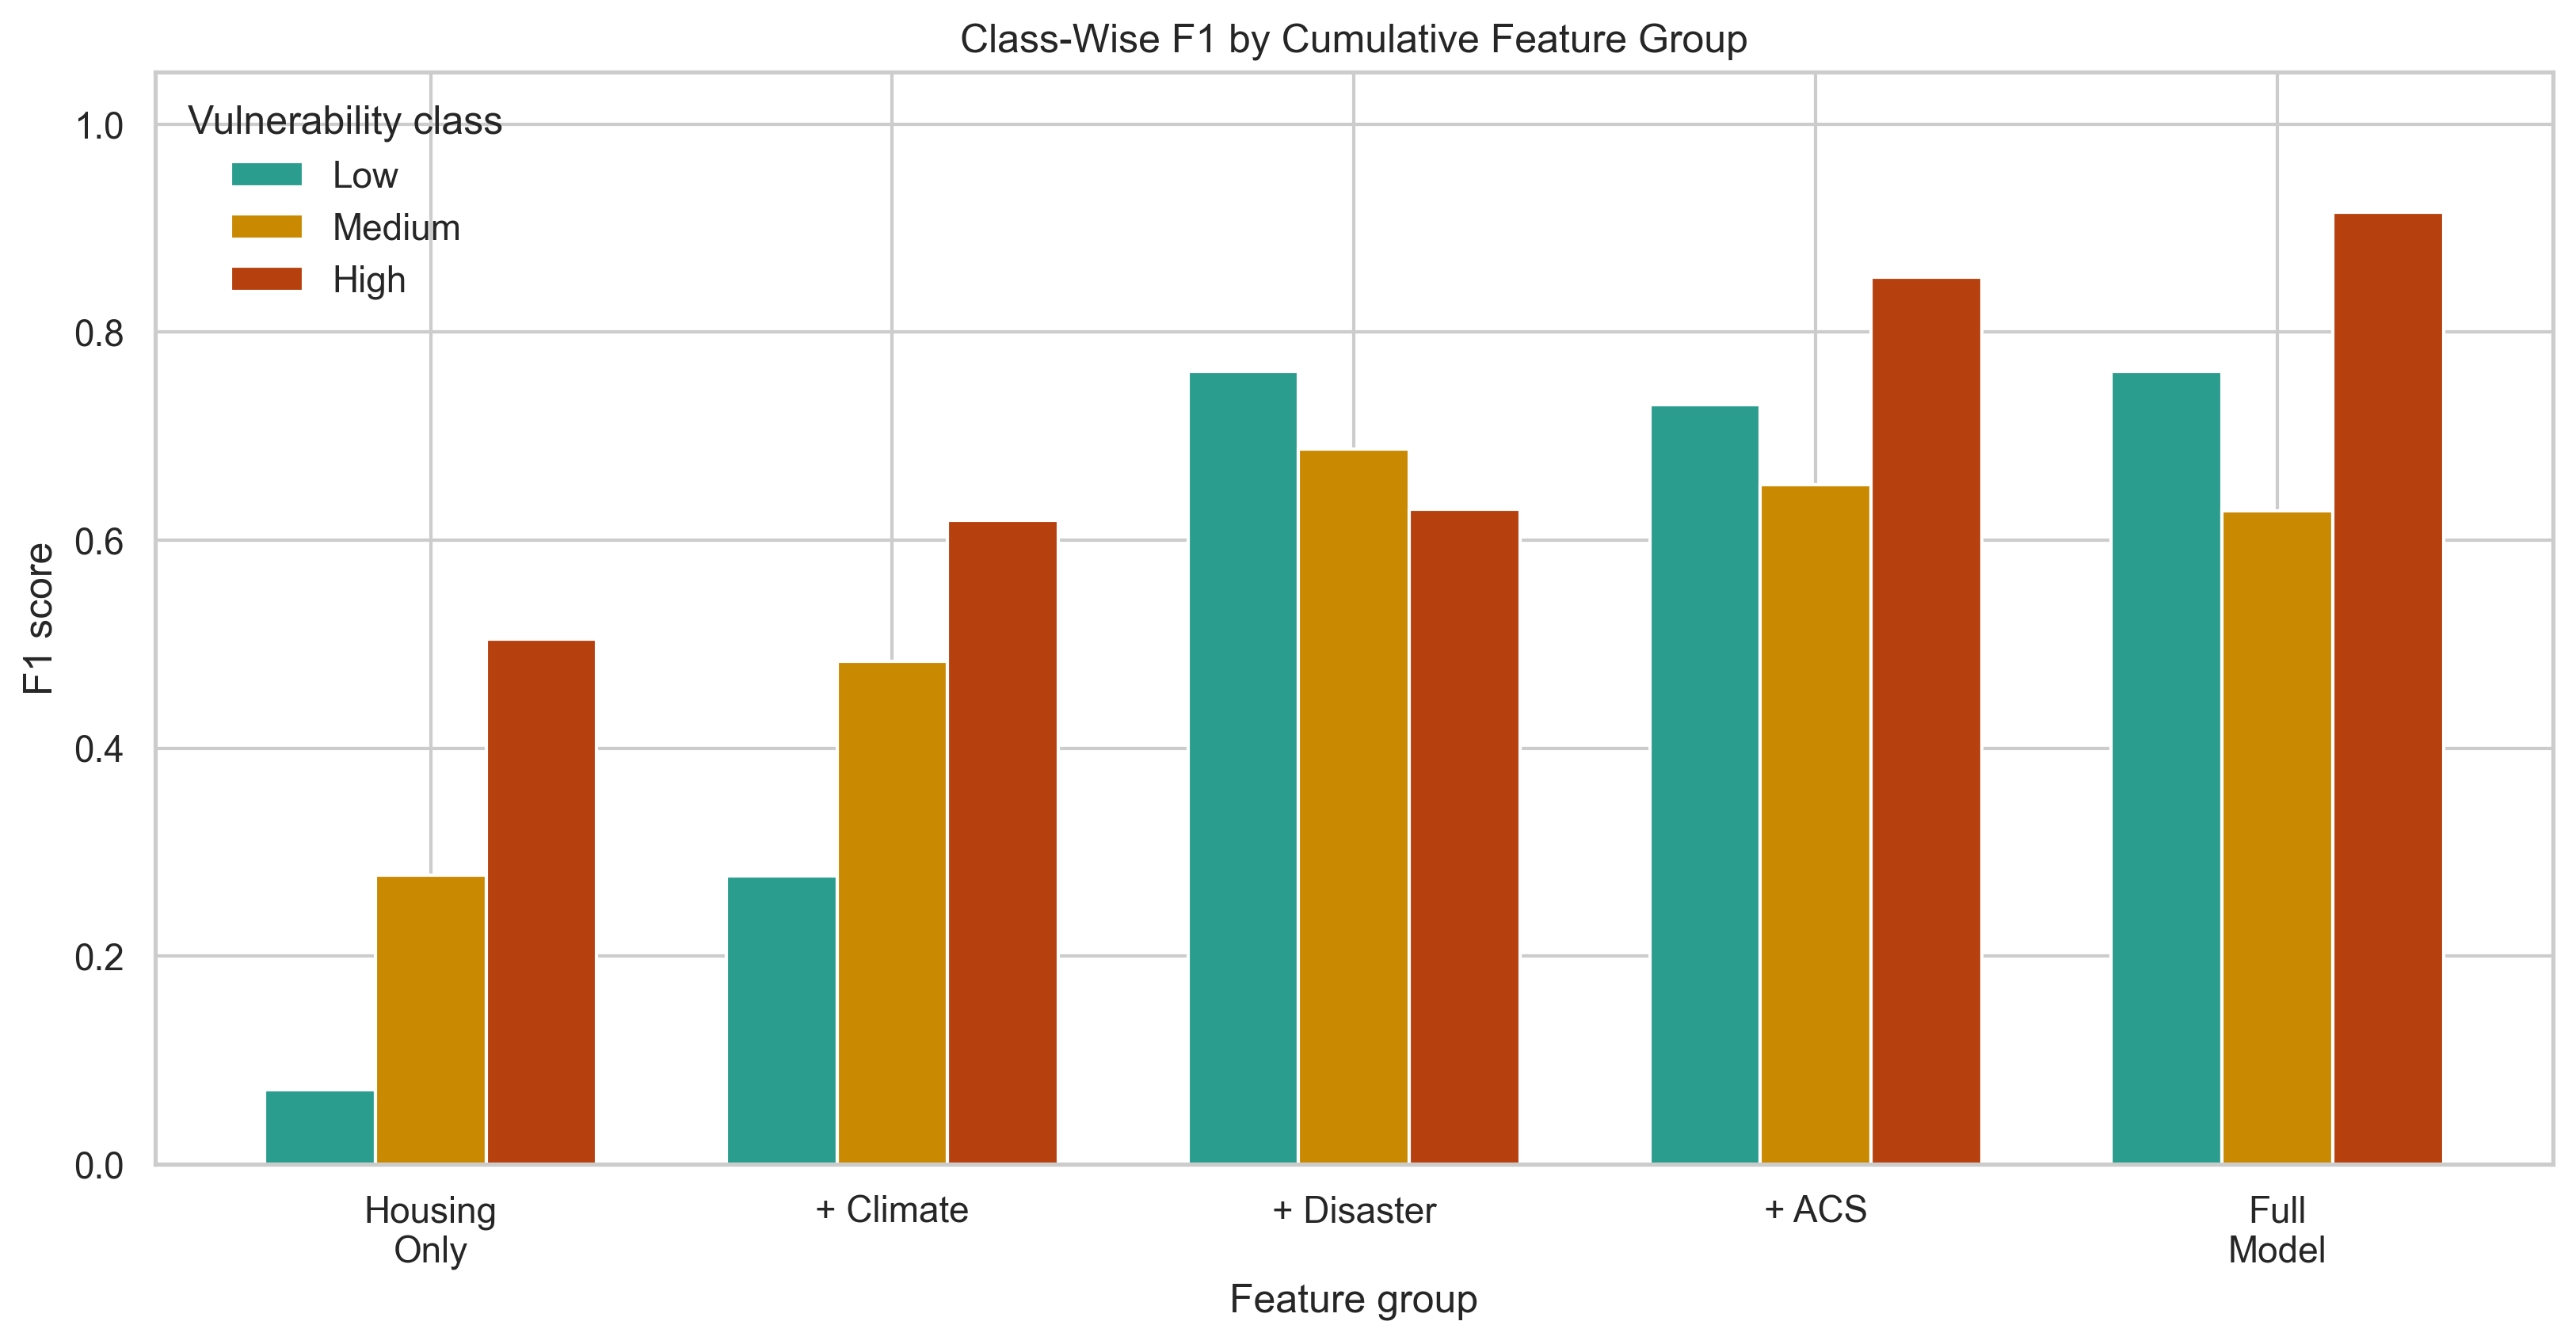

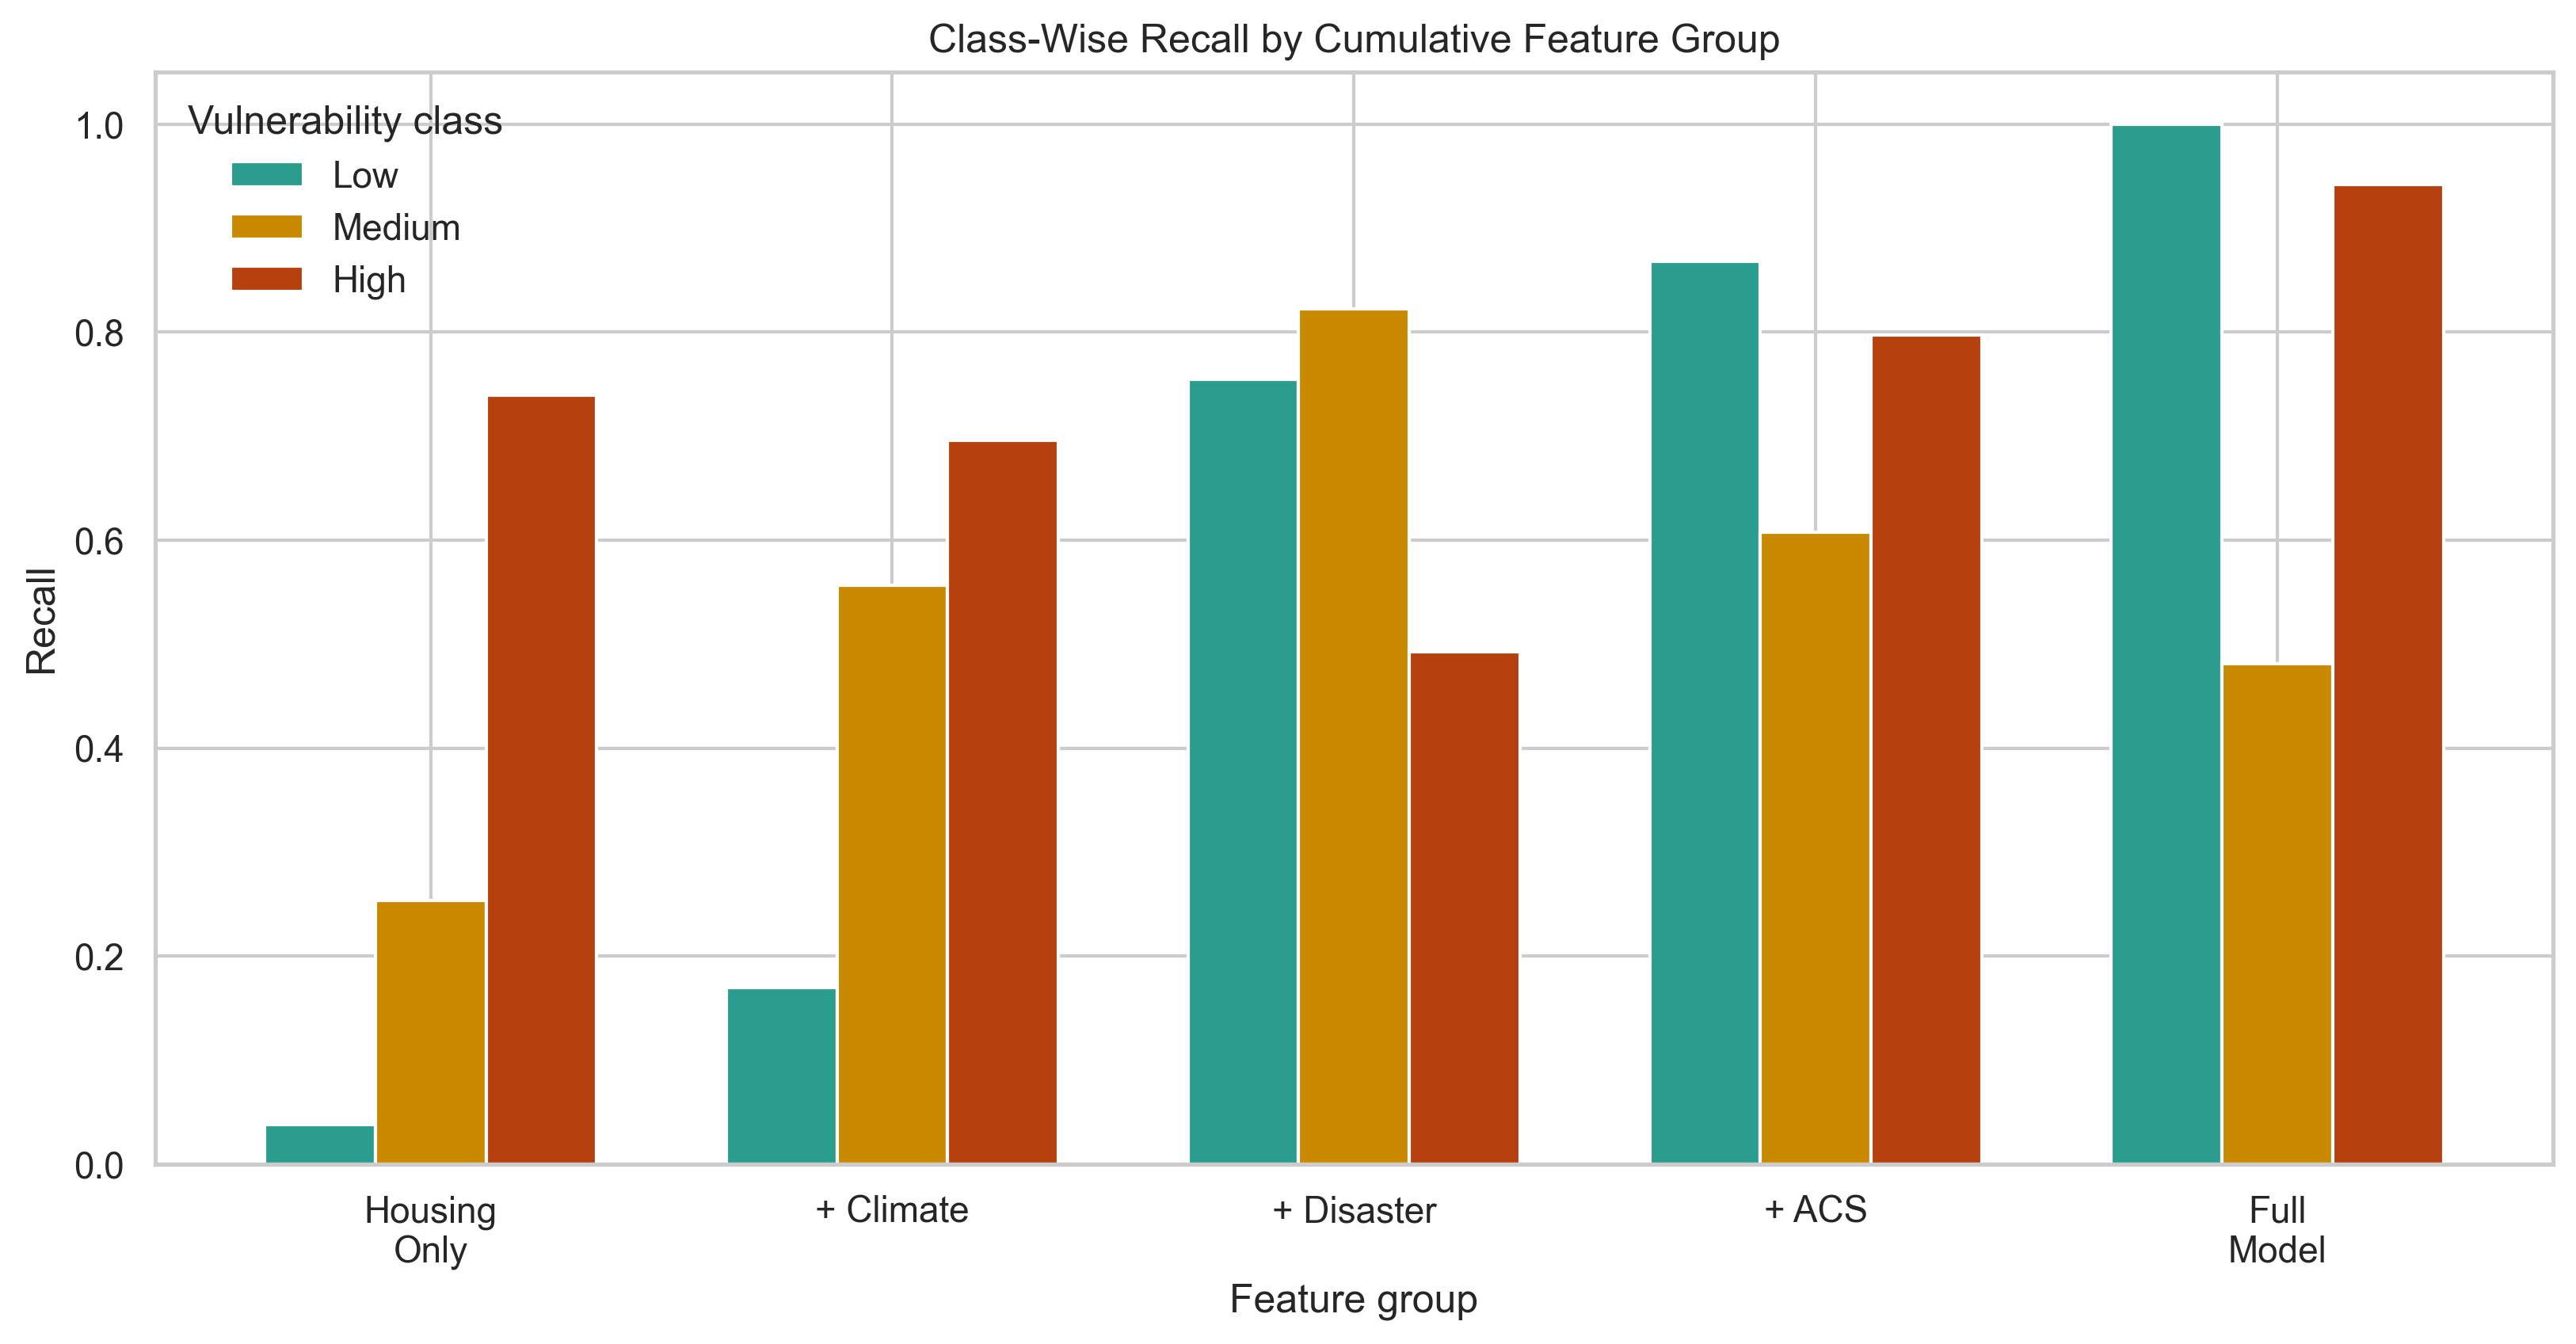

In [10]:
SHORT_GROUP_LABELS = ["Housing\nOnly", "+ Climate", "+ Disaster", "+ ACS", "Full\nModel"]
x = np.arange(len(FEATURE_GROUP_ORDER))

# Overall macro F1 curve
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(
    x,
    feature_group_comparison["test_macro_f1"],
    color=PROJECT_COLORS["housing"],
    marker="o",
    linewidth=2.4,
    label="2023–2025 held-out macro F1",
)
ax.plot(
    x,
    feature_group_comparison["cv_macro_f1_mean"],
    color=PROJECT_COLORS["neutral"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Mean temporal-CV macro F1",
)
for index, value in enumerate(feature_group_comparison["test_macro_f1"]):
    ax.annotate(f"{value:.3f}", (index, value), xytext=(0, 9), textcoords="offset points", ha="center")
ax.set(title="Macro F1 by Cumulative Feature Group", xlabel="Feature group", ylabel="Macro F1")
ax.set_xticks(x, SHORT_GROUP_LABELS)
ax.set_ylim(0, 0.9)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
macro_f1_path = RESULTS_FIGURES / "feature_group_macro_f1_curve.png"
save_figure(fig, macro_f1_path)
plt.close(fig)

# Marginal held-out contribution
marginal_plot = marginal_contribution.iloc[1:].copy()
layer_colors = [
    PROJECT_COLORS["climate"],
    PROJECT_COLORS["disaster"],
    PROJECT_COLORS["social"],
    PROJECT_COLORS["nfip"],
]
fig, ax = plt.subplots(figsize=(9.5, 5.8))
bars = ax.bar(
    np.arange(4), marginal_plot["delta_test_macro_f1"], color=layer_colors, width=0.68
)
ax.bar_label(bars, labels=[f"+{v:.3f}" for v in marginal_plot["delta_test_macro_f1"]], padding=4)
ax.axhline(0, color=PROJECT_COLORS["neutral"], linewidth=1)
ax.set(
    title="Marginal Gain in Held-Out Macro F1",
    xlabel="Added feature layer",
    ylabel="Change in macro F1",
    xticks=np.arange(4),
    xticklabels=["Climate", "Disaster", "ACS", "NFIP + Spatial"],
)
ax.set_ylim(0, marginal_plot["delta_test_macro_f1"].max() + 0.07)
fig.tight_layout()
marginal_path = RESULTS_FIGURES / "feature_group_marginal_contribution.png"
save_figure(fig, marginal_path)
plt.close(fig)


def plot_classwise_metric(metric, ylabel, title, output_name):
    pivot = classwise_performance.pivot(
        index="feature_group", columns="class", values=metric
    ).reindex(index=FEATURE_GROUP_ORDER, columns=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(11, 5.8))
    width = 0.24
    for offset, class_name in zip([-width, 0, width], CLASS_ORDER):
        ax.bar(
            x + offset,
            pivot[class_name],
            width=width,
            color=CLASS_COLORS[class_name],
            label=class_name,
        )
    ax.set(title=title, xlabel="Feature group", ylabel=ylabel)
    ax.set_xticks(x, SHORT_GROUP_LABELS)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Vulnerability class", frameon=False)
    fig.tight_layout()
    output_path = RESULTS_FIGURES / output_name
    save_figure(fig, output_path)
    plt.close(fig)
    return output_path


classwise_f1_path = plot_classwise_metric(
    "f1_score",
    "F1 score",
    "Class-Wise F1 by Cumulative Feature Group",
    "feature_group_classwise_f1.png",
)
classwise_recall_path = plot_classwise_metric(
    "recall",
    "Recall",
    "Class-Wise Recall by Cumulative Feature Group",
    "feature_group_classwise_recall.png",
)

for figure_path in [macro_f1_path, marginal_path, classwise_f1_path, classwise_recall_path]:
    display(Image(filename=str(figure_path), width=800))


## 11. Export reproducible outputs

The complete definitions, split settings, fold results, predictions, diagnostics, and statistical-test details are exported. Notebook 08 reads the overall comparison, marginal contribution, class-wise performance, and feature definitions directly from this directory.


In [11]:
OUTPUT_PATHS = {
    "Feature-group validation": RESULTS_TABLES / "feature_group_validation.csv",
    "Temporal CV fold summary": RESULTS_TABLES / "feature_group_cv_fold_summary.csv",
    "Temporal CV results": RESULTS_TABLES / "feature_group_cv_results.csv",
    "Held-out results": RESULTS_TABLES / "feature_group_holdout_results.csv",
    "Overall comparison": RESULTS_TABLES / "feature_group_overall_comparison.csv",
    "Marginal contribution": RESULTS_TABLES / "feature_group_marginal_contribution.csv",
    "Class-wise performance": RESULTS_TABLES / "feature_group_classwise_performance.csv",
    "Confusion matrix": RESULTS_TABLES / "feature_group_confusion_matrix_long.csv",
    "Held-out predictions": RESULTS_TABLES / "feature_group_test_predictions.csv",
    "Climate paired folds": RESULTS_TABLES / "climate_feature_paired_fold_results.csv",
    "Climate paired t-test": RESULTS_TABLES / "climate_feature_paired_ttest_summary.csv",
    "Definitions": RESULTS_TABLES / "feature_group_definitions.json",
}

TABLE_EXPORTS = {
    "Feature-group validation": feature_group_validation,
    "Temporal CV fold summary": cv_fold_summary,
    "Temporal CV results": cv_results,
    "Held-out results": holdout_results,
    "Overall comparison": feature_group_comparison,
    "Marginal contribution": marginal_contribution,
    "Class-wise performance": classwise_performance,
    "Confusion matrix": confusion_matrix_long,
    "Held-out predictions": test_predictions,
    "Climate paired folds": paired_macro_f1,
    "Climate paired t-test": climate_paired_ttest_summary,
}
for artifact, dataframe in TABLE_EXPORTS.items():
    save_table(dataframe, OUTPUT_PATHS[artifact])

feature_group_metadata = {
    "feature_group_order": FEATURE_GROUP_ORDER,
    "validated_feature_groups": {
        group: list(features) for group, features in validated_feature_groups.items()
    },
    "number_of_features_by_group": {
        group: len(features) for group, features in validated_feature_groups.items()
    },
    "class_order": CLASS_ORDER,
    "project_period": {
        "project_start_year": STUDY_START_YEAR,
        "project_end_year": STUDY_END_YEAR,
        "train_end_year": TRAIN_END_YEAR,
        "test_start_year": TEST_START_YEAR,
    },
    "model_settings": {
        "model": "Logistic Regression",
        "random_state": RANDOM_STATE,
        "primary_evaluation_metric": "Macro F1",
        "scikit_learn_version": sklearn.__version__,
    },
    "cv_fold_definitions": CV_FOLD_DEFINITIONS,
    "statistical_test": {
        "test_name": "Paired-samples t-test",
        "baseline_feature_group": "Housing Only",
        "enhanced_feature_group": "Housing + Climate",
        "paired_metric": "Macro F1",
        "number_of_temporal_folds": len(paired_macro_f1),
        "alternative": "two-sided",
        "significance_level": 0.05,
        "confidence_level": 0.95,
        "difference_direction": "Housing + Climate minus Housing Only",
        "interpretation_scope": (
            "Performance difference within five aligned, overlapping expanding-window "
            "temporal cross-validation folds; interpreted as supporting evidence"
        ),
        "scipy_version": scipy.__version__,
    },
}
OUTPUT_PATHS["Definitions"].write_text(
    json.dumps(feature_group_metadata, indent=4), encoding="utf-8"
)

export_summary = pd.DataFrame(
    {
        "artifact": OUTPUT_PATHS.keys(),
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in OUTPUT_PATHS.values()],
    }
)

print(f"Saved {len(OUTPUT_PATHS)} feature-group artifacts.")
display(export_summary)


Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_validation.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_cv_fold_summary.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_cv_results.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_holdout_results.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_overall_comparison.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\feature_group_comparison\feature_group_marginal_contribution.csv
Saved table: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-h

,artifact,path
0,Feature-group validation,results\tables\feature_group_comparison\featur...
1,Temporal CV fold summary,results\tables\feature_group_comparison\featur...
2,Temporal CV results,results\tables\feature_group_comparison\featur...
3,Held-out results,results\tables\feature_group_comparison\featur...
4,Overall comparison,results\tables\feature_group_comparison\featur...
5,Marginal contribution,results\tables\feature_group_comparison\featur...
6,Class-wise performance,results\tables\feature_group_comparison\featur...
7,Confusion matrix,results\tables\feature_group_comparison\featur...
8,Held-out predictions,results\tables\feature_group_comparison\featur...
9,Climate paired folds,results\tables\feature_group_comparison\climat...


## 12. Key findings

Housing indicators alone provide weak later-period discrimination (macro F1 = 0.285). Adding the two climate-exposure indicators raises macro F1 to 0.460, and disaster history produces the largest additional held-out gain, reaching 0.693. Socioeconomic and affordability conditions raise performance to 0.745, while the Full Model reaches 0.769 after adding NFIP loss history and spatial spillovers.

The pattern supports the study’s central conclusion: housing-market performance captures only part of climate-housing vulnerability. Broader climate, disaster, community, insurance-loss, and spatial conditions contribute information that housing indicators alone do not reveal. The Medium class remains the most difficult category, while the Full Model most clearly separates the Low and High extremes.
